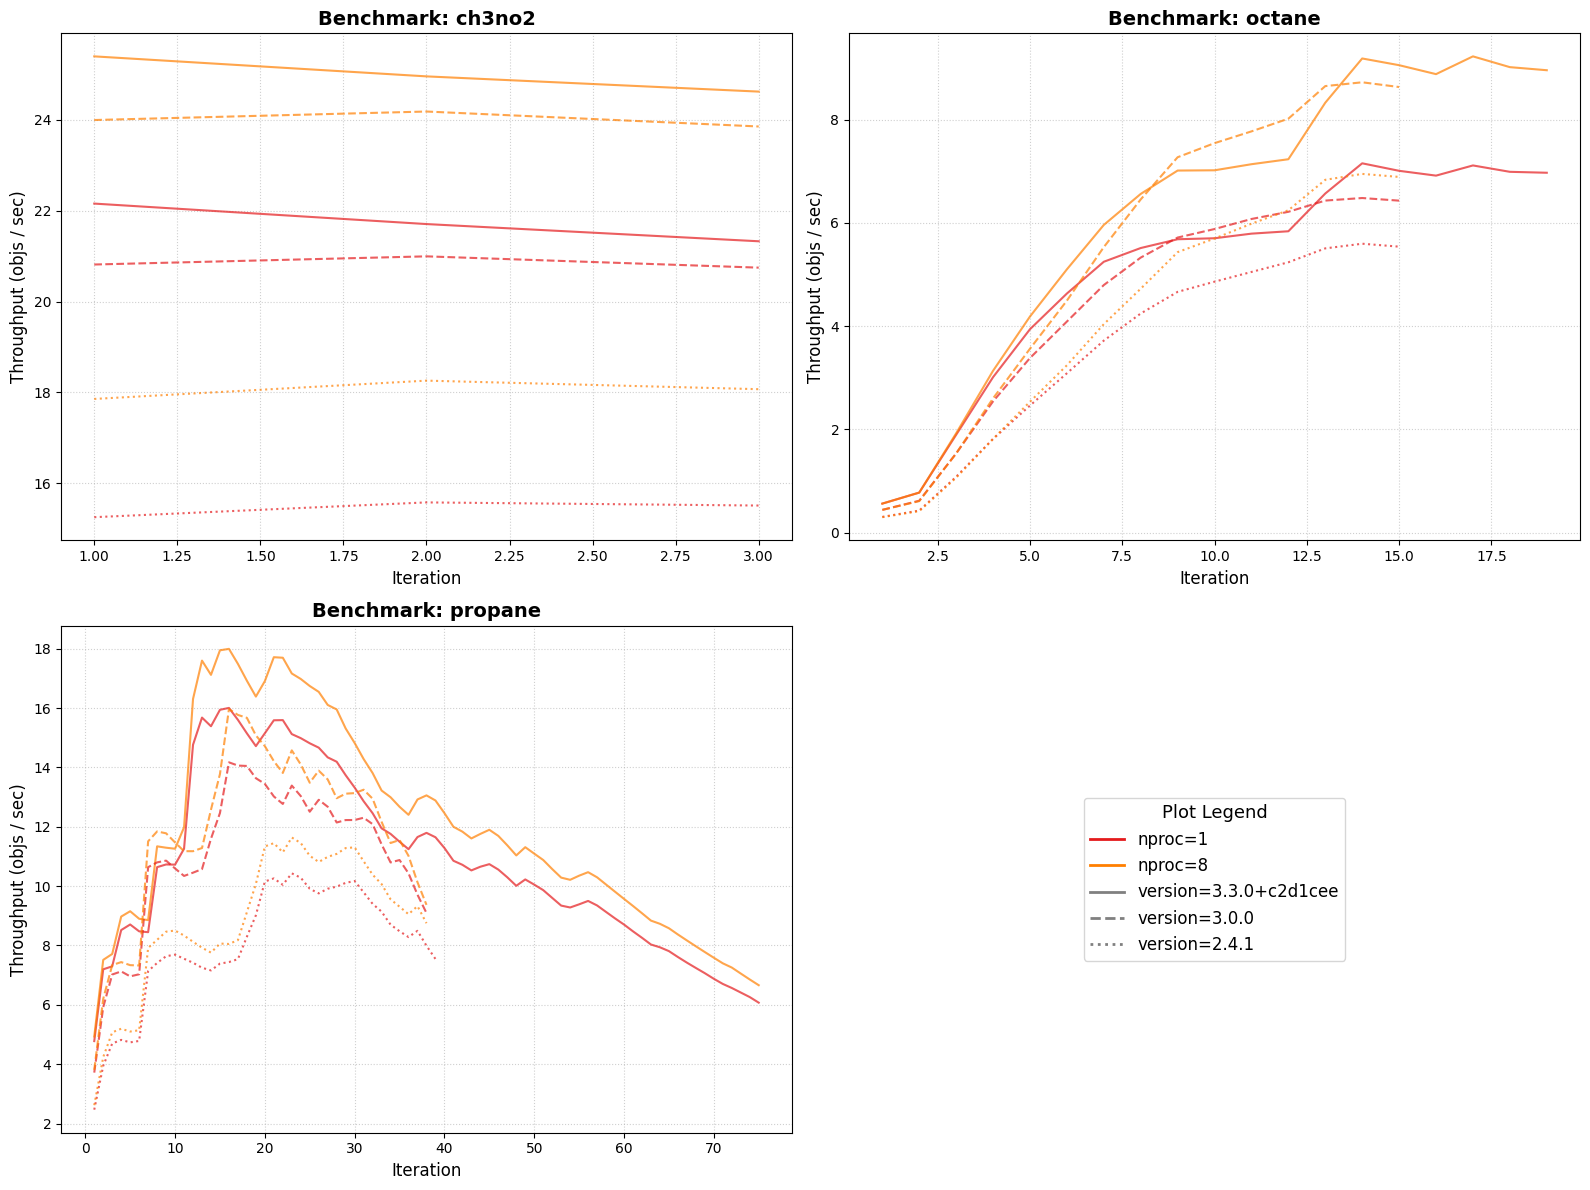

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load data
src = Path('rmgpy_output_20260310_103030/benchmark_summary.csv')
df = pd.read_csv(src)

df = df[~df['nproc'].isin((2, 4))]

# Parsing time
def parse_time(time_str):
    parts = time_str.split(':')
    if len(parts) == 4:
        d, h, m, s = map(int, parts)
        return d * 86400 + h * 3600 + m * 60 + s
    return 0

df['total_seconds'] = df['exec_time_dd_hh_mm_ss'].apply(parse_time)
df['total_objects'] = df['core_species'] + df['core_reactions'] + df['edge_species'] + df['edge_reactions']
# Replace 0 with 1 to avoid division by zero (though total_seconds is unlikely 0)
df['throughput'] = df['total_objects'] / df['total_seconds'].replace(0, 1)

# Sorting values
df = df.sort_values(by=['benchmark', 'version', 'nproc', 'iteration'])

benchmarks = sorted(df['benchmark'].unique())
nprocs = sorted(df['nproc'].unique())
versions = ("3.3.0+c2d1cee", "3.0.0", "2.4.1")

# Setup colors and styles
# Color for nproc
nproc_colors = {np: plt.cm.Set1(i/len(nprocs)) for i, np in enumerate(nprocs)}
# Style for versions
version_styles = {v: style for v, style in zip(versions, ['-', '--', ':'])}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Place for lines to gather handles
# We will create manual legend entries to avoid repeats
legend_elements = []
for np in nprocs:
    legend_elements.append(Line2D([0], [0], color=nproc_colors[np], lw=2, label=f"nproc={np}"))
for v in versions:
    legend_elements.append(Line2D([0], [0], color='gray', linestyle=version_styles[v], lw=2, label=f"version={v}"))

for i, bench in enumerate(benchmarks):
    ax = axes[i]
    bench_df = df[df['benchmark'] == bench]
    
    for v in versions:
        for np in nprocs:
            subset = bench_df[(bench_df['version'] == v) & (bench_df['nproc'] == np)]
            if not subset.empty:
                ax.plot(subset['iteration'], subset['throughput'], 
                         color=nproc_colors[np], 
                         linestyle=version_styles[v],
                         marker='o', markersize=0, alpha=0.7)
    
    ax.set_title(f"Benchmark: {bench}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Iteration", fontsize=12)
    ax.set_ylabel("Throughput (objs / sec)", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

# Legend tile
ax_legend = axes[3]
ax_legend.axis('off')
ax_legend.legend(handles=legend_elements, loc='center', title="Plot Legend", fontsize=12, title_fontsize=13, ncol=1)

plt.tight_layout()
plt.savefig(src.parent.resolve() / 'throughput_benchmark_plot.png')
plt.show()